<a href="https://colab.research.google.com/github/vinodponmadyl/Iris-Flower-Classification/blob/main/%20Setup%20GA%20Fuzzy%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.6 MB/s eta 0:00:00


In [5]:
import numpy as np
import skfuzzy as fuzz
x_temp = np.arange(0, 41, 1)   # Temperature universe: 0–40°C
x_fan  = np.arange(0, 101, 1)  # Fan speed universe: 0–100%
def build_fuzzy_system(chromosome):
    low_c, low_w, med_c, med_w, high_c, high_w = chromosome

    mf_low  = fuzz.trimf(x_temp, [low_c-low_w,  low_c,  low_c+low_w])
    mf_med  = fuzz.trimf(x_temp, [med_c-med_w,  med_c,  med_c+med_w])
    mf_high = fuzz.trimf(x_temp, [high_c-high_w, high_c, high_c+high_w])

    return mf_low, mf_med, mf_high

In [6]:
!pip install scikit-fuzzy deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.6 MB/s eta 0:00:00


In [7]:
import numpy as np
import skfuzzy as fuzz
from deap import base, creator, tools, algorithms
import random

x_temp = np.arange(0, 41, 1)   # Temperature universe: 0–40°C
x_fan  = np.arange(0, 101, 1)  # Fan speed universe: 0–100%

def build_fuzzy_system(chromosome):
    low_c, low_w, med_c, med_w, high_c, high_w = chromosome

    # Ensure widths are positive and centers are ordered (basic validity)
    low_w = max(0.1, low_w)
    med_w = max(0.1, med_w)
    high_w = max(0.1, high_w)

    # Adjust centers if they are out of order, or too close
    low_c = np.clip(low_c, x_temp.min(), x_temp.max() - 2 * low_w)
    med_c = np.clip(med_c, low_c + low_w, x_temp.max() - high_w)
    high_c = np.clip(high_c, med_c + med_w, x_temp.max())


    mf_low  = fuzz.trimf(x_temp, [low_c-low_w,  low_c,  low_c+low_w])
    mf_med  = fuzz.trimf(x_temp, [med_c-med_w,  med_c,  med_c+med_w])
    mf_high = fuzz.trimf(x_temp, [high_c-high_w, high_c, high_c+high_w])

    return mf_low, mf_med, mf_high

# GA parameters
POPULATION_SIZE = 50
GENERATIONS = 50
CXPB = 0.7  # Crossover probability
MUTPB = 0.2 # Mutation probability

# Bounds for chromosome values
# Each chromosome will have 6 values: [low_c, low_w, med_c, med_w, high_c, high_w]
# Centers (c) typically within x_temp range (0-40)
# Widths (w) can vary, but should be reasonable (e.g., 1-15)
BOUND_LOW  = [0, 1, 0, 1, 0, 1]   # Min possible value for each parameter
BOUND_HIGH = [40, 15, 40, 15, 40, 15] # Max possible value for each parameter


Next, we'll define the fitness function. For this example, a simple fitness function will be used that aims to create well-distributed and non-overlapping membership functions. A more sophisticated fitness function would require a specific control problem or dataset to optimize against.

In [8]:
# Define the fitness function
def evaluate(individual):
    mf_low, mf_med, mf_high = build_fuzzy_system(individual)

    # Fitness criteria:
    # 1. Coverage: Ensure the MFs cover the universe of discourse reasonably
    # 2. Non-overlap: Penalize excessive overlap between adjacent MFs
    # 3. Shape: Encourage well-formed triangular MFs

    # Simple approach: Maximize the total area under the MFs, and penalize overlap
    area_low = np.sum(mf_low)
    area_med = np.sum(mf_med)
    area_high = np.sum(mf_high)

    total_area = area_low + area_med + area_high

    # Overlap penalty (e.g., sum of min(mf1, mf2))
    overlap_low_med = np.sum(np.fmin(mf_low, mf_med))
    overlap_med_high = np.sum(np.fmin(mf_med, mf_high))

    # We want to maximize coverage and minimize overlap
    # A higher total_area and lower overlap is better.
    # So, we maximize total_area - overlap_penalty
    fitness = total_area - (overlap_low_med + overlap_med_high) * 2 # Multiply overlap penalty to make it significant

    # Also, add a penalty for invalid or ill-formed MFs (e.g., if widths are too small or centers are unordered)
    low_c, low_w, med_c, med_w, high_c, high_w = individual
    penalty = 0
    if low_w <= 0.1 or med_w <= 0.1 or high_w <= 0.1: # Very small widths
        penalty += 100
    if med_c <= low_c or high_c <= med_c: # Centers not ordered
        penalty += 100
    if low_c - low_w < x_temp.min() or high_c + high_w > x_temp.max(): # MFs going out of bounds
        penalty += 50


    return fitness - penalty, # DEAP expects a tuple for fitness values

Now, we will set up the DEAP toolbox for the Genetic Algorithm, including defining the individual, population, selection, crossover, and mutation operations.

In [9]:
# DEAP setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator: float values within specified bounds
# The chromosome has 6 genes: low_c, low_w, med_c, med_w, high_c, high_w
for i in range(6):
    tool = lambda i=i: random.uniform(BOUND_LOW[i], BOUND_HIGH[i])
    tool_name = f'attr_gene_{i}'
    tool_func = tool
    tool_func.__name__ = tool_name
    toolbox.register(tool_name, tool_func)

# Individual generator: list of 6 genes
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_gene_0, toolbox.attr_gene_1, toolbox.attr_gene_2,
                  toolbox.attr_gene_3, toolbox.attr_gene_4, toolbox.attr_gene_5), n=1)

# Population generator
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Genetic operators
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=[0]*6, sigma=[5]*6, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)


Finally, we will run the Genetic Algorithm to find the best chromosome (set of membership function parameters).

In [10]:
def run_ga():
    pop = toolbox.population(n=POPULATION_SIZE)

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    # Begin the evolution
    for g in range(GENERATIONS):
        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # The population is replaced by the offspring
        pop[:] = offspring

    best_ind = tools.selBest(pop, 1)[0]
    return best_ind, pop

best_chromosome, final_population = run_ga()
print("Best individual is %s, with fitness: %s" % (best_chromosome, best_chromosome.fitness.values))


Best individual is [18.09271730974907, 15.80095818049882, 27.01005205916488, 11.014218298418426, 28.10315152698753, 5.939596272227893], with fitness: (np.float64(25.714147519408776),)


Now, let's visualize the membership functions found by the Genetic Algorithm.

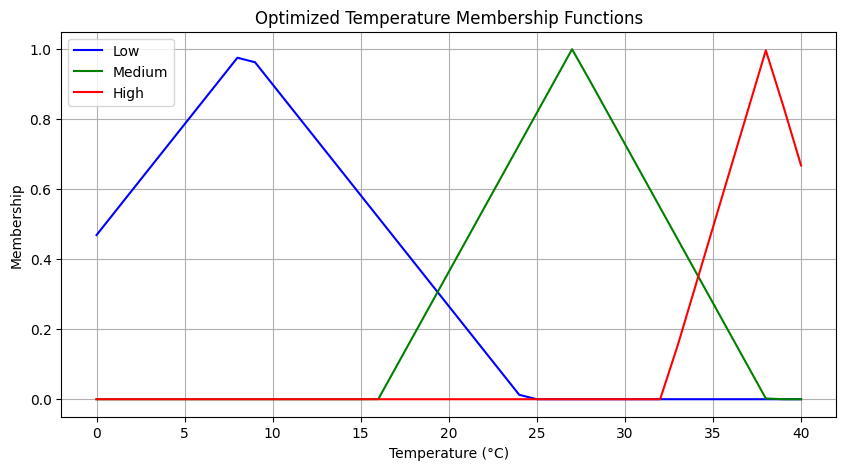

In [11]:
import matplotlib.pyplot as plt

mf_low_best, mf_med_best, mf_high_best = build_fuzzy_system(best_chromosome)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_temp, mf_low_best, 'b', linewidth=1.5, label='Low')
ax.plot(x_temp, mf_med_best, 'g', linewidth=1.5, label='Medium')
ax.plot(x_temp, mf_high_best, 'r', linewidth=1.5, label='High')
ax.set_title('Optimized Temperature Membership Functions')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Membership')
ax.legend()
ax.grid(True)
plt.show()